In [4]:
import pandas as pd
import SimpleITK as sitk
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
import ast

In [ ]:
df_pre_data = pd.read_csv(r'preprocessing_log.csv')

In [ ]:
df_pre_data[df_pre_data['status']=='Failed'].to_csv('failed_preprocessing_temp.csv', index=False)

In [ ]:
df_pre_data.dtypes

In [ ]:
df_pre_data_suc = df_pre_data[df_pre_data['status']=='Success'].copy()

In [ ]:
df_pre_data_suc.shape

In [ ]:
df_pre_data_suc

In [ ]:
df_pre_data_suc['shape_z_y_x'] = df_pre_data_suc['shape_z_y_x'].apply(ast.literal_eval)

In [ ]:
def find_area(x):
    x,y,z= x
    return x*y*z

In [ ]:
df_pre_data_suc['area'] = df_pre_data_suc['shape_z_y_x'].apply(find_area)

In [ ]:
sns.boxplot(x=df_pre_data_suc['area'])

In [ ]:
list_of_files = os.listdir(r'processed_data')

In [7]:
train_df = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train.csv')

In [10]:
train_df[train_df['Modality']=='CTA']['Aneurysm Present'].value_counts()

Aneurysm Present
1    997
0    860
Name: count, dtype: int64

In [ ]:
prep_df = pd.DataFrame((files[:-7] for files in list_of_files), columns=['SeriesInstanceUID'])
prep_df.iloc[3].values


In [ ]:
prep_df = prep_df.merge(train_df, how='inner', on='SeriesInstanceUID')
prep_df


In [ ]:
list_seg = os.listdir(r'rsna-intracranial-aneurysm-detection\segmentations')

In [ ]:
list_seg

In [39]:
from view3d_data import *
from preprocess_ct import *

In [ ]:
seg_mask = sitk.ReadImage(str(r'rsna-intracranial-aneurysm-detection\segmentations\1.2.826.0.1.3680043.8.498.10076056930521523789588901704956188485\1.2.826.0.1.3680043.8.498.10076056930521523789588901704956188485.nii'))

In [ ]:
seg_mask_np = sitk.GetArrayFromImage(seg_mask)
seg_mask_np.shape

In [ ]:
view_3d_volume(seg_mask_np)

In [ ]:
import numpy as np

print("Unique values in mask:", np.unique(seg_mask_np))
print("Number of aneurysm voxels:", np.sum(seg_mask_np > 0))


In [ ]:
train_df[train_df['SeriesInstanceUID']=='1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381']

In [ ]:
local_df = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train_localizers.csv')
local_df

In [1]:
import pandas as pd
df_new_logs = pd.read_csv(r'processed_data_v2\preprocessing_log.csv')
df_new_logs  = df_new_logs[df_new_logs['status']!='Skipped']
df_new_logs

,SeriesInstanceUID,status,shape_z_y_x,error
0,1.2.826.0.1.3680043.8.498.10035643165968342618...,Success,"(133, 349, 295)",NaN
1,1.2.826.0.1.3680043.8.498.10077108087009955586...,Success,"(167, 250, 394)",NaN
2,1.2.826.0.1.3680043.8.498.10192011262895867728...,Failed,NaN,need at least one array to stack
3,1.2.826.0.1.3680043.8.498.10291305271924252800...,Failed,NaN,need at least one array to stack
4,1.2.826.0.1.3680043.8.498.10311178483256099259...,Success,"(8, 135, 69)",NaN
...,...,...,...,...
389,1.2.826.0.1.3680043.8.498.99614492920407247894...,Success,"(178, 346, 272)",NaN
390,1.2.826.0.1.3680043.8.498.99639493469775227910...,Success,"(98, 325, 290)",NaN
391,1.2.826.0.1.3680043.8.498.99674090910456004499...,Success,"(143, 348, 266)",NaN
392,1.2.826.0.1.3680043.8.498.99887675554378211308...,Success,"(81, 231, 231)",NaN


In [ ]:
df_new_logs.to_csv(r'processed_data_v2\preprocessing_log.csv', index=False)

In [ ]:
df_new_logs = pd.read_csv(r'processed_data_v2\preprocessing_log.csv')
df_o_logs = pd.read_csv(r'processed_data_v2\preprocessing_log_1.csv')

In [ ]:
df_o_logs = df_o_logs[~df_o_logs['SeriesInstanceUID'].isin(df_new_logs['SeriesInstanceUID'])]

In [ ]:
df_o_logs[df_o_logs['SeriesInstanceUID'].isin(df_new_logs['SeriesInstanceUID'])]

In [ ]:
df_all_logs = pd.concat([df_new_logs, df_o_logs])
df_all_logs

In [ ]:
df_all_logs.to_csv('df_all_processing_logs.csv',index=False)

In [ ]:
df_new_localization = pd.read_csv(r'processed_data_v2\new_localization.csv')
df_old_localization = pd.read_csv(r'processed_data_v2\new_localization_1.csv')

In [ ]:
df_new_localization['SeriesInstanceUID'].value_counts()

In [ ]:
df_old_localization['SeriesInstanceUID'].value_counts()

In [ ]:
df_old_localization = df_old_localization[~df_old_localization['SeriesInstanceUID'].isin(df_new_localization['SeriesInstanceUID'])]
df_old_localization

In [ ]:
df_all_localization = pd.concat([df_new_localization, df_old_localization])
df_all_localization

In [ ]:
df_all_localization['SeriesInstanceUID'].nunique()

In [ ]:
df_all_localization.to_csv(r'df_all_localization.csv', index=False)

In [ ]:
df_train = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train.csv')
df_train

In [ ]:
df_train[df_train['Modality']=='CTA']['Aneurysm Present'].value_counts()

In [ ]:
master_df = pd.merge(df_all_localization,df_train , how='left', on='SeriesInstanceUID')
master_df

In [ ]:
master_df['Aneurysm Present'].value_counts()

In [ ]:
df_train[df_train['Modality']=='CTA']['Aneurysm Present'].value_counts()

In [ ]:
master_df.to_csv(r'master_df_positive_ct.csv', index=False)

In [ ]:
# Step 1: split into columns
master_df[['coord_z', 'coord_y', 'coord_x']] = (
    master_df['final_coords_zyx']
    .str.strip("()")               # remove parentheses
    .str.split(",", expand=True)   # split into 3 columns
)

# Step 2: clean whitespace and stray characters
for col in ['coord_z', 'coord_y', 'coord_x']:
    master_df[col] = master_df[col].str.strip().str.replace(")", "").str.replace("(", "")

# Step 3: convert safely to numeric
master_df[['coord_z', 'coord_y', 'coord_x']] = master_df[['coord_z', 'coord_y', 'coord_x']].apply(
    pd.to_numeric, errors='coerce'   # invalid values -> NaN instead of error
)

# Optional: drop the original column
master_df.drop(columns=['final_coords_zyx'], inplace=True)

master_df.head()

In [ ]:
# master_df.drop(columns=['final_coords_zyx'], inplace=True)
master_df[['coord_z', 'coord_y', 'coord_x']] = master_df[['coord_z', 'coord_y', 'coord_x']].apply(pd.to_numeric)

In [ ]:
master_df.columns

In [2]:
import seaborn as sns

In [ ]:
sns.pairplot(master_df[['coord_z', 'coord_y', 'coord_x' ]], diag_kind='kde')

In [ ]:
#read all seriesUID from traindf and add them to masterdf if the same seriesUID is not present and aneurysm present for that seriesUID is 0 in masterdf and set default values for all other columsn
master_df = pd.merge(df_train,df_all_localization, how='left', on='SeriesInstanceUID')

In [ ]:
neg_cases = df_train[(df_train['Aneurysm Present'] == 0) & (df_train['Modality'] == 'CTA')]
neg_cases

In [ ]:
master_df = pd.concat([master_df,neg_cases])
master_df

In [ ]:
master_df[master_df['Aneurysm Present'] == 0]

In [ ]:
master_df['SeriesInstanceUID'].nunique()

In [ ]:
# Save as check_data_consistency.py
import pandas as pd
import os

# --- CONFIGURE THESE ---
MASTER_CSV_PATH = 'master_df_positive_ct.csv'
NPY_DATA_DIR = 'processed_data_npy'
# ---------------------

print("--- Running Data Consistency Check ---")

# 1. Get all unique UIDs from the CSV file
try:
    df_master = pd.read_csv(MASTER_CSV_PATH)
    csv_uids = set(df_master['SeriesInstanceUID'].unique())
    print(f"Found {len(csv_uids)} unique SeriesInstanceUIDs in {MASTER_CSV_PATH}")
except FileNotFoundError:
    print(f"ERROR: Master CSV not found at {MASTER_CSV_PATH}")
    exit()

# 2. Get all UIDs from the .npy files on disk
try:
    # Get all filenames, remove the '.npy' extension to get the UID
    file_uids = set([f.replace('.npy', '') for f in os.listdir(NPY_DATA_DIR) if f.endswith('.npy')])
    print(f"Found {len(file_uids)} .npy files in {NPY_DATA_DIR}")
except FileNotFoundError:
    print(f"ERROR: NPY data directory not found at {NPY_DATA_DIR}")
    exit()

print("-" * 30)

# 3. Find the differences
files_not_in_csv = file_uids - csv_uids
csv_uids_not_in_files = csv_uids - file_uids

if not files_not_in_csv and not csv_uids_not_in_files:
    print("SUCCESS: Data is perfectly consistent!")
else:
    if files_not_in_csv:
        print(f"\nWARNING: Found {len(files_not_in_csv)} .npy files that are NOT listed in the master CSV:")
        for uid in files_not_in_csv:
            print(f" -> {uid}")
        print("(This is OK if these files are intentionally excluded, e.g., negative cases.)")

    if csv_uids_not_in_files:
        print(f"\nWARNING: Found {len(csv_uids_not_in_files)} UIDs in the CSV that are MISSING their .npy file:")
        for uid in csv_uids_not_in_files:
            print(f" -> {uid}")
        print("(This is expected for scans that failed during preprocessing.)")

print("\n--- Check Complete ---")

In [3]:
train_manif = pd.read_csv(r'aneurysm_dataset_manifests\test_manifest.csv')

In [5]:
train_manif['Aneurysm Present'].value_counts()

Aneurysm Present
0    15553
1      850
Name: count, dtype: int64

In [6]:
master_df = pd.read_csv(r'master_df_positive_ct.csv')
master_df['Aneurysm Present'].value_counts()

Aneurysm Present
1    1235
0     860
Name: count, dtype: int64

In [18]:
train_manif = pd.read_csv(r'aneurysm_dataset_manifests\train_manifest.csv')


In [20]:
train_manif['Aneurysm Present'].value_counts()

Aneurysm Present
0    208449
1      5875
Name: count, dtype: int64

In [ ]:
# Save this as balance_dataset.py

import pandas as pd
import os

# --- 1. CONFIGURATION ---

# The directory where your train/test/val manifest CSVs are saved
MANIFEST_DIR = 'aneurysm_dataset_manifests_padded' 

# The directory where the new, balanced manifests will be saved
OUTPUT_DIR = 'aneurysm_dataset_manifests_balanced'

# --- SAMPLING PARAMETERS ---
# We want a ratio of NEGATIVE_RATIO negatives for every 1 positive.
# 2.0 means a 2:1 ratio of negative to positive patches.
NEGATIVE_RATIO = 1.68

# --- 2. SCRIPT LOGIC ---

def balance_manifests():
    """
    Loads the generated manifest files, downsamples the negative cases in the
    training and validation sets, and saves new, balanced CSVs.
    The test set is left untouched to provide an unbiased evaluation.
    """
    print("--- Starting Manifest Balancing ---")
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # We only balance the training and validation sets.
    # The test set must remain in its original, imbalanced distribution
    # to give a true measure of real-world performance.
    for split in ['train', 'validation', 'test']:
        input_path = os.path.join(MANIFEST_DIR, f"{split}_manifest.csv")
        output_path = os.path.join(OUTPUT_DIR, f"{split}_manifest.csv")

        try:
            df = pd.read_csv(input_path)
        except FileNotFoundError:
            print(f"Warning: Manifest file not found at {input_path}. Skipping.")
            continue

        print(f"\nProcessing {split}_manifest.csv...")
        
        if split in ['test','validation']:
            print(" -> Test set is not balanced. Copying as is.")
            df.to_csv(output_path, index=False)
            continue

        # Separate positive and negative patches
        df_pos = df[df['Aneurysm Present'] == 1]
        df_neg = df[df['Aneurysm Present'] == 0]

        n_pos = len(df_pos)
        n_neg_desired = int(n_pos * NEGATIVE_RATIO)

        print(f" -> Found {n_pos} positive patches.")
        print(f" -> Found {len(df_neg)} negative patches.")
        
        if len(df_neg) < n_neg_desired:
            print(f" -> Warning: Not enough negative samples to meet the desired ratio. Using all {len(df_neg)} negative samples.")
            df_neg_sampled = df_neg
        else:
            print(f" -> Sampling {n_neg_desired} negative patches...")
            # Randomly sample the negative patches
            df_neg_sampled = df_neg.sample(n=n_neg_desired, random_state=42)

        # Combine the positive and sampled negative patches
        df_balanced = pd.concat([df_pos, df_neg_sampled])
        
        # Shuffle the final dataframe to mix positive and negative samples
        df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

        print(f" -> Saving balanced manifest with {len(df_balanced)} total patches to {output_path}")
        df_balanced.to_csv(output_path, index=False)

    print("\n--- Balancing Complete ---")
    print(f"All balanced manifest files saved in: {OUTPUT_DIR}")

if __name__ == '__main__':
    balance_manifests()

--- Starting Manifest Balancing ---

Processing train_manifest.csv...
 -> Found 6896 positive patches.
 -> Found 108522 negative patches.
 -> Sampling 11585 negative patches...
 -> Saving balanced manifest with 18481 total patches to aneurysm_dataset_manifests_balanced\train_manifest.csv

Processing validation_manifest.csv...
 -> Test set is not balanced. Copying as is.

Processing test_manifest.csv...
 -> Test set is not balanced. Copying as is.

--- Balancing Complete ---
All balanced manifest files saved in: aneurysm_dataset_manifests_balanced


In [29]:
train_manif = pd.read_csv(r'aneurysm_dataset_manifests\train_manifest.csv')
print(train_manif['Aneurysm Present'].value_counts().sum())
print(train_manif['Aneurysm Present'].value_counts()[1]/train_manif['Aneurysm Present'].value_counts().sum())
train_manif['Aneurysm Present'].value_counts()

233895
0.06593984480215481


Aneurysm Present
0    218472
1     15423
Name: count, dtype: int64

In [30]:
train_manif['series_uid'].value_counts()

series_uid
1.2.826.0.1.3680043.8.498.70549153055776520915952933860351851348    1456
1.2.826.0.1.3680043.8.498.64879378184322937470205790810927082379    1008
1.2.826.0.1.3680043.8.498.70128862898305387932830693881247457838    1008
1.2.826.0.1.3680043.8.498.92998683254509169763575328138377737464     975
1.2.826.0.1.3680043.8.498.51622072109491849550446237355180890093     924
                                                                    ... 
1.2.826.0.1.3680043.8.498.52743250257981808315549480384122614395      21
1.2.826.0.1.3680043.8.498.50462346896825686194809696037436442493      16
1.2.826.0.1.3680043.8.498.11810118622295763293156375884304476552      16
1.2.826.0.1.3680043.8.498.10311178483256099259176768310869377326       3
1.2.826.0.1.3680043.8.498.45837832166169483827461218048825117162       1
Name: count, Length: 1276, dtype: int64

<Axes: xlabel='count'>

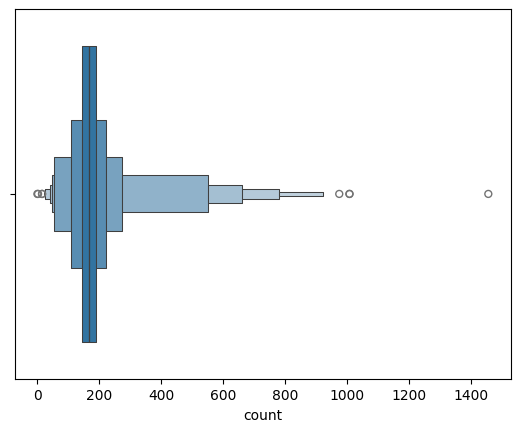

In [31]:
sns.boxenplot(x=train_manif['series_uid'].value_counts())

In [33]:
test_manif = pd.read_csv(r'aneurysm_dataset_manifests\test_manifest.csv')
print(test_manif['Aneurysm Present'].value_counts().sum())
print(test_manif['Aneurysm Present'].value_counts()[1]/test_manif['Aneurysm Present'].value_counts().sum())
test_manif['Aneurysm Present'].value_counts()

32738
0.061335451157676094


Aneurysm Present
0    30730
1     2008
Name: count, dtype: int64

In [34]:
validation_manif = pd.read_csv(r'aneurysm_dataset_manifests\validation_manifest.csv')
print(validation_manif['Aneurysm Present'].value_counts().sum())
print(validation_manif['Aneurysm Present'].value_counts()[1]/validation_manif['Aneurysm Present'].value_counts().sum())
validation_manif['Aneurysm Present'].value_counts()

66011
0.06601929981366741


Aneurysm Present
0    61653
1     4358
Name: count, dtype: int64

In [42]:
import os
import matplotlib.pyplot as plt
f= 'rsna-intracranial-aneurysm-detection\series'
def disp_dist_3d(img_name,sof_tissue_range_hu: tuple = (-100,400),DEBUG_MODE=False):
    img_path = os.path.join(f,img_name)
    proc_img_np = preprocess_cta_scan(img_path,cta_hu_window=sof_tissue_range_hu,DEBUG_MODE=DEBUG_MODE)[0]
    view_3d_volume(proc_img_np)
    display_hu_distribution(proc_img_np)

interactive(children=(IntSlider(value=83, description='slice_index', max=166), FloatSlider(value=0.0, descript…

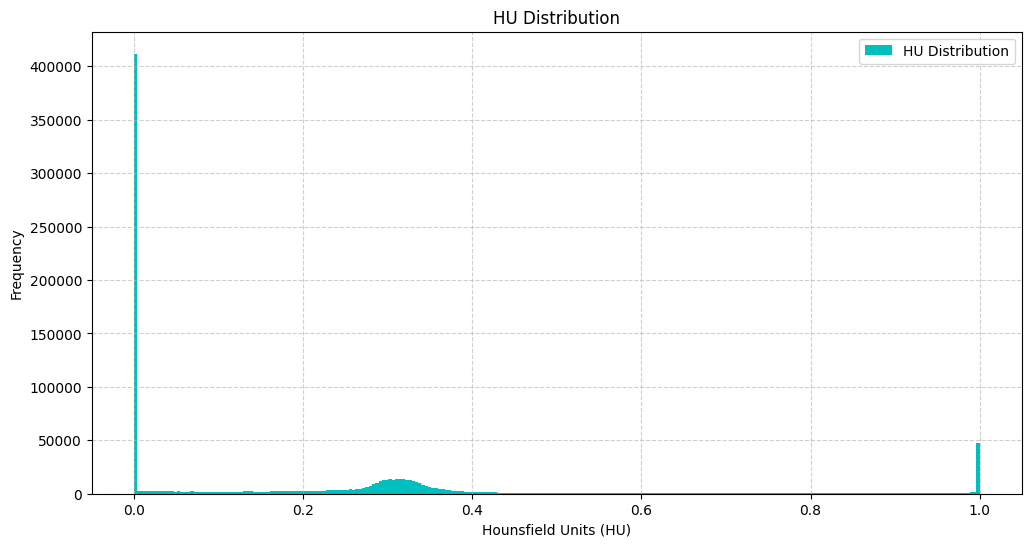

In [43]:
disp_dist_3d(r'1.2.826.0.1.3680043.8.498.10077108087009955586144859725246456654')

In [66]:
df = pd.read_csv(r'processed_data_v3\new_localization.csv')
# df.drop_duplicates(inplace=True)
df['SeriesInstanceUID'].value_counts()

SeriesInstanceUID
1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381    3
1.2.826.0.1.3680043.8.498.10077108087009955586144859725246456654    2
1.2.826.0.1.3680043.8.498.10022796280698534221758473208024838831    1
1.2.826.0.1.3680043.8.498.10030095840917973694487307992374923817    1
1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557    1
1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317    1
1.2.826.0.1.3680043.8.498.10042474696169267476037627878420766468    1
1.2.826.0.1.3680043.8.498.10086325220791440678552106812785190149    1
1.2.826.0.1.3680043.8.498.10092666779602341135460882241562348436    1
1.2.826.0.1.3680043.8.498.10095912539619532839962135126795591815    1
1.2.826.0.1.3680043.8.498.10118104902601294641571465174067732646    1
1.2.826.0.1.3680043.8.498.10126487256624050201543415947047895825    1
1.2.826.0.1.3680043.8.498.10129580404994628606227497184499173213    1
1.2.826.0.1.3680043.8.498.10133805409448598100180344093077653742    1
Na

In [57]:
df2= pd.read_csv(r'processed_data_v3\preprocessing_log.csv')
df2

,SeriesInstanceUID,status,shape_z_y_x,error
0,1.2.826.0.1.3680043.8.498.10005158603912009425...,Success,"(92, 318, 283)",NaN
1,1.2.826.0.1.3680043.8.498.10014757658335054766...,Success,"(152, 318, 262)",NaN
2,1.2.826.0.1.3680043.8.498.10021411248005513321...,Success,"(139, 347, 279)",NaN
3,1.2.826.0.1.3680043.8.498.10022796280698534221...,Success,"(157, 331, 265)",NaN
4,1.2.826.0.1.3680043.8.498.10030095840917973694...,Success,"(144, 325, 275)",NaN
5,1.2.826.0.1.3680043.8.498.10034081836061566510...,Success,"(170, 351, 342)",NaN
6,1.2.826.0.1.3680043.8.498.10035643165968342618...,Success,"(133, 349, 295)",NaN
7,1.2.826.0.1.3680043.8.498.10042474696169267476...,Success,"(139, 313, 276)",NaN
8,1.2.826.0.1.3680043.8.498.10048925006598672000...,Success,"(159, 361, 295)",NaN
9,1.2.826.0.1.3680043.8.498.10052893794239333131...,Success,"(100, 345, 345)",NaN


In [67]:
df_train = pd.read_csv(r'rsna-intracranial-aneurysm-detection\train_localizers.csv')
df_train[ df_train['SeriesInstanceUID'].isin(df2['SeriesInstanceUID'])]['SeriesInstanceUID'].value_counts()

SeriesInstanceUID
1.2.826.0.1.3680043.8.498.10035643165968342618460849823699311381    3
1.2.826.0.1.3680043.8.498.10077108087009955586144859725246456654    2
1.2.826.0.1.3680043.8.498.10022796280698534221758473208024838831    1
1.2.826.0.1.3680043.8.498.10030095840917973694487307992374923817    1
1.2.826.0.1.3680043.8.498.10034081836061566510187499603024895557    1
1.2.826.0.1.3680043.8.498.10005158603912009425635473100344077317    1
1.2.826.0.1.3680043.8.498.10042474696169267476037627878420766468    1
1.2.826.0.1.3680043.8.498.10086325220791440678552106812785190149    1
1.2.826.0.1.3680043.8.498.10092666779602341135460882241562348436    1
1.2.826.0.1.3680043.8.498.10095912539619532839962135126795591815    1
1.2.826.0.1.3680043.8.498.10118104902601294641571465174067732646    1
1.2.826.0.1.3680043.8.498.10126487256624050201543415947047895825    1
1.2.826.0.1.3680043.8.498.10129580404994628606227497184499173213    1
1.2.826.0.1.3680043.8.498.10133805409448598100180344093077653742    1
Na

# -------------

In [ ]:
# Save this as reconcile_localizations.py

import pandas as pd
import numpy as np
from tqdm import tqdm
import os
import SimpleITK as sitk
import pydicom
import ast
from scipy.spatial.distance import euclidean

# --- 1. CONFIGURATION ---

# --- INPUT PATHS ---
# Path to the localization file generated by your preprocessing (with final z,y,x voxel coords)
NEW_LOCALIZATION_CSV = r'df_all_localization_ct.csv'

# Path to the ORIGINAL competition localization file (with 2D pixel coords and location strings)
ORIGINAL_LOCALIZERS_CSV = r'rsna-intracranial-aneurysm-detection/train_localizers.csv'

# Path to the folder containing your FINAL PROCESSED .nii.gz files
PROCESSED_NIFTI_DIR = r'processed_data_v2' # The folder with .nii.gz files

# Path to the folder containing the ORIGINAL DICOM series folders
ORIGINAL_DICOM_DIR = r'rsna-intracranial-aneurysm-detection/series'

# --- OUTPUT PATH ---
# The full path where the final, corrected master CSV will be saved
CORRECTED_MASTER_CSV_PATH = r'master_df_corrected.csv'


# --- 2. HELPER FUNCTIONS ---

def get_physical_point_from_final_scan(series_uid, final_voxel_coords_zyx):
    """
    Converts a final voxel coordinate (z,y,x) from a processed NIfTI file
    back into its real-world physical LPS coordinate.
    """
    nifti_path = os.path.join(PROCESSED_NIFTI_DIR, f"{series_uid}.nii.gz")
    try:
        itk_image = sitk.ReadImage(nifti_path)
        # SimpleITK expects (x, y, z) order for its methods
        coords_xyz = final_voxel_coords_zyx[::-1]
        physical_point = itk_image.TransformIndexToPhysicalPoint([int(c) for c in coords_xyz])
        return physical_point
    except Exception as e:
        # print(f"Warning: Could not process NIfTI for {series_uid}: {e}")
        return None

def get_physical_point_from_original_scan(series_uid, sop_uid, coords_xy_dict):
    """
    Converts an original 2D pixel coordinate (x,y) from a specific DICOM slice
    into its real-world physical LPS coordinate.
    """
    dicom_folder_path = os.path.join(ORIGINAL_DICOM_DIR, series_uid)
    for filename in os.listdir(dicom_folder_path):
        filepath = os.path.join(dicom_folder_path, filename)
        if not os.path.isfile(filepath): continue
        try:
            dcm = pydicom.dcmread(filepath, stop_before_pixels=True)
            if hasattr(dcm, 'SOPInstanceUID') and dcm.SOPInstanceUID == sop_uid:
                img_pos_patient = np.array(dcm.ImagePositionPatient, dtype=float)
                img_orient_patient = np.array(dcm.ImageOrientationPatient, dtype=float)
                pixel_spacing = np.array(dcm.PixelSpacing, dtype=float)
                row_vec = img_orient_patient[3:6]
                col_vec = img_orient_patient[0:3]
                x_coord = float(coords_xy_dict['x'])
                y_coord = float(coords_xy_dict['y'])
                physical_coords = img_pos_patient + (x_coord * pixel_spacing[0] * col_vec) + (y_coord * pixel_spacing[1] * row_vec)
                return tuple(physical_coords)
        except Exception:
            continue
    return None # Return None if the SOP UID is not found

# --- 3. MAIN SCRIPT LOGIC ---

def reconcile_localizations():
    """
    Main function to match aneurysms by physical proximity and create a corrected master CSV.
    """
    print("--- Starting Localization Reconciliation ---")

    # --- A. LOAD AND PREPARE DATA ---
    try:
        df_new = pd.read_csv(NEW_LOCALIZATION_CSV)
        df_original = pd.read_csv(ORIGINAL_LOCALIZERS_CSV)
    except FileNotFoundError as e:
        print(f"ERROR: Could not find a required file. {e}")
        return

    # Parse string coordinates into tuples/dicts
    df_new['final_coords_zyx'] = df_new['final_coords_zyx'].apply(ast.literal_eval)
    df_original['coordinates'] = df_original['coordinates'].apply(ast.literal_eval)
    
    # Identify scans with multiple aneurysms that need careful matching
    uid_counts = df_original['SeriesInstanceUID'].value_counts()
    uids_to_match = uid_counts[uid_counts > 1].index.tolist()
    
    all_corrected_rows = []
    print(f"Found {len(uids_to_match)} scans with multiple aneurysms to reconcile.")

    # --- B. PROCESS MULTI-ANEURYSM SCANS ---
    for series_uid in tqdm(uids_to_match, desc="Reconciling Scans"):
        # Get the lists of aneurysms for this scan from both files
        new_aneurysms = df_new[df_new['SeriesInstanceUID'] == series_uid].to_dict('records')
        original_aneurysms = df_original[df_original['SeriesInstanceUID'] == series_uid].to_dict('records')

        if len(new_aneurysms) != len(original_aneurysms):
            print(f"\nWarning: Mismatch in aneurysm count for {series_uid}. New file has {len(new_aneurysms)}, original has {len(original_aneurysms)}. Skipping.")
            continue

        # Calculate physical points for all aneurysms in this scan
        new_points = [{'data': an, 'point': get_physical_point_from_final_scan(series_uid, an['final_coords_zyx'])} for an in new_aneurysms]
        original_points = [{'data': an, 'point': get_physical_point_from_original_scan(series_uid, an['SOPInstanceUID'], an['coordinates'])} for an in original_aneurysms]
        
        # Filter out any that failed to convert
        new_points = [p for p in new_points if p['point'] is not None]
        original_points = [p for p in original_points if p['point'] is not None]

        if not new_points or not original_points:
            print(f"\nWarning: Could not calculate physical points for {series_uid}. Skipping.")
            continue
            
        # --- The Core Matching Logic ---
        matched_originals = set()
        for new_p in new_points:
            distances = [euclidean(new_p['point'], orig_p['point']) for orig_p in original_points]
            
            best_match_idx = np.argmin(distances)
            min_dist = distances[best_match_idx]

            if min_dist > 5.0: # 5mm threshold for a valid match
                print(f"\nWarning: No confident match found for an aneurysm in {series_uid}. Minimum distance was {min_dist:.2f}mm. Skipping this point.")
                continue

            # Check if this original point has already been matched
            if best_match_idx in matched_originals:
                print(f"\nWarning: Ambiguous match for {series_uid}. Multiple points mapping to the same original location. Skipping scan.")
                # Break the inner loop and move to the next scan
                break 
            
            matched_originals.add(best_match_idx)
            matched_original_data = original_points[best_match_idx]['data']
            
            # Create the corrected row
            corrected_row = {
                'SeriesInstanceUID': series_uid,
                'final_coords_zyx': new_p['data']['final_coords_zyx'],
                'location': matched_original_data['location']
            }
            all_corrected_rows.append(corrected_row)
        else: # This 'else' belongs to the 'for' loop, executes if the loop completes without 'break'
            continue
        break # This executes if the inner 'for' loop was broken

    df_corrected_multi = pd.DataFrame(all_corrected_rows)

    # --- C. PROCESS SINGLE-ANEURYSM SCANS ---
    uids_single = uid_counts[uid_counts == 1].index.tolist()
    df_new_singles = df_new[df_new['SeriesInstanceUID'].isin(uids_single)]
    df_original_singles = df_original[df_original['SeriesInstanceUID'].isin(uids_single)]
    # For single cases, we can merge directly by UID
    df_corrected_singles = pd.merge(
        df_new_singles[['SeriesInstanceUID', 'final_coords_zyx']],
        df_original_singles[['SeriesInstanceUID', 'location']],
        on='SeriesInstanceUID'
    )

    # --- D. COMBINE AND ONE-HOT ENCODE ---
    print("\nCombining results and performing one-hot encoding...")
    df_all_positives = pd.concat([df_corrected_multi, df_corrected_singles], ignore_index=True)

    # Add back the negative cases from the new file
    df_negatives = df_new[df_new['final_coords_zyx'].apply(lambda x: isinstance(x, tuple) and any(c < 0 for c in x) or not isinstance(x, tuple))].copy()
    df_negatives['location'] = 'Negative'
    
    df_final = pd.concat([df_all_positives, df_negatives[['SeriesInstanceUID', 'final_coords_zyx', 'location']]], ignore_index=True)
    
    # One-hot encode the 'location' column
    df_final['Aneurysm Present'] = (df_final['location'] != 'Negative').astype(int)
    location_dummies = pd.get_dummies(df_final['location'])
    
    # Ensure all possible artery columns exist
    location_cols = [
        'Left Infraclinoid Internal Carotid Artery', 'Right Infraclinoid Internal Carotid Artery',
        'Left Supraclinoid Internal Carotid Artery', 'Right Supraclinoid Internal Carotid Artery',
        'Left Middle Cerebral Artery', 'Right Middle Cerebral Artery',
        'Anterior Communicating Artery', 'Left Anterior Cerebral Artery',
        'Right Anterior Cerebral Artery', 'Left Posterior Communicating Artery',
        'Right Posterior Communicating Artery', 'Basilar Tip', 'Other Posterior Circulation'
    ]
    for col in location_cols:
        if col not in location_dummies.columns:
            location_dummies[col] = 0
            
    df_final = pd.concat([df_final, location_dummies], axis=1)

    # --- E. FINAL CLEANUP AND SAVE ---
    # Recreate coord columns for clarity and consistency
    coords = pd.DataFrame(df_final['final_coords_zyx'].tolist(), index=df_final.index, columns=['coord_z', 'coord_y', 'coord_x'])
    df_final = pd.concat([df_final, coords], axis=1)

    final_cols = ['SeriesInstanceUID', 'Aneurysm Present', 'coord_z', 'coord_y', 'coord_x'] + location_cols
    df_final = df_final[final_cols]
    
    print(f"Saving new corrected master file to {CORRECTED_MASTER_CSV_PATH}...")
    df_final.to_csv(CORRECTED_MASTER_CSV_PATH, index=False)
    print("--- Reconciliation Complete ---")

if __name__ == '__main__':
    reconcile_localizations()

In [36]:
import torch
from monai.bundle import ConfigParser

# --- Part 1: Analyze SegResNet ---
print("--- Analyzing SegResNet ---")
cfg_seg = ConfigParser()
cfg_seg.read_config("models/wholeBody_ct_segmentation/configs/inference.json")

# This line reads the config and creates the PyTorch model object
segresnet_model = cfg_seg.get_parsed_content("network_def")

# Print the entire model architecture
segresnet_model

--- Analyzing SegResNet ---


SegResNet(
  (act_mod): ReLU(inplace=True)
  (convInit): Convolution(
    (conv): Conv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  )
  (down_layers): ModuleList(
    (0): Sequential(
      (0): Identity()
      (1): ResBlock(
        (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
        (act): ReLU(inplace=True)
        (conv1): Convolution(
          (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
        (conv2): Convolution(
          (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        )
      )
    )
    (1): Sequential(
      (0): Convolution(
        (conv): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      )
      (1): ResBlock(
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 64, eps=1e-05, a

In [ ]:
# --- Part 2: Analyze Swin UNETR ---
print("\n\n--- Analyzing Swin UNETR ---")
cfg_swin = ConfigParser()
cfg_swin.read("models/swin_unetr_btcv_segmentation/configs/inference.json")

swin_model = cfg_swin.get_parsed_content("network")

swin_model

In [ ]:
!pip install prophet


00:21:08 - cmdstanpy - INFO - Chain [1] start processing
00:21:08 - cmdstanpy - INFO - Chain [1] done processing
00:21:08 - cmdstanpy - INFO - Chain [1] start processing
00:21:08 - cmdstanpy - INFO - Chain [1] done processing
00:21:08 - cmdstanpy - INFO - Chain [1] start processing
00:21:09 - cmdstanpy - INFO - Chain [1] done processing


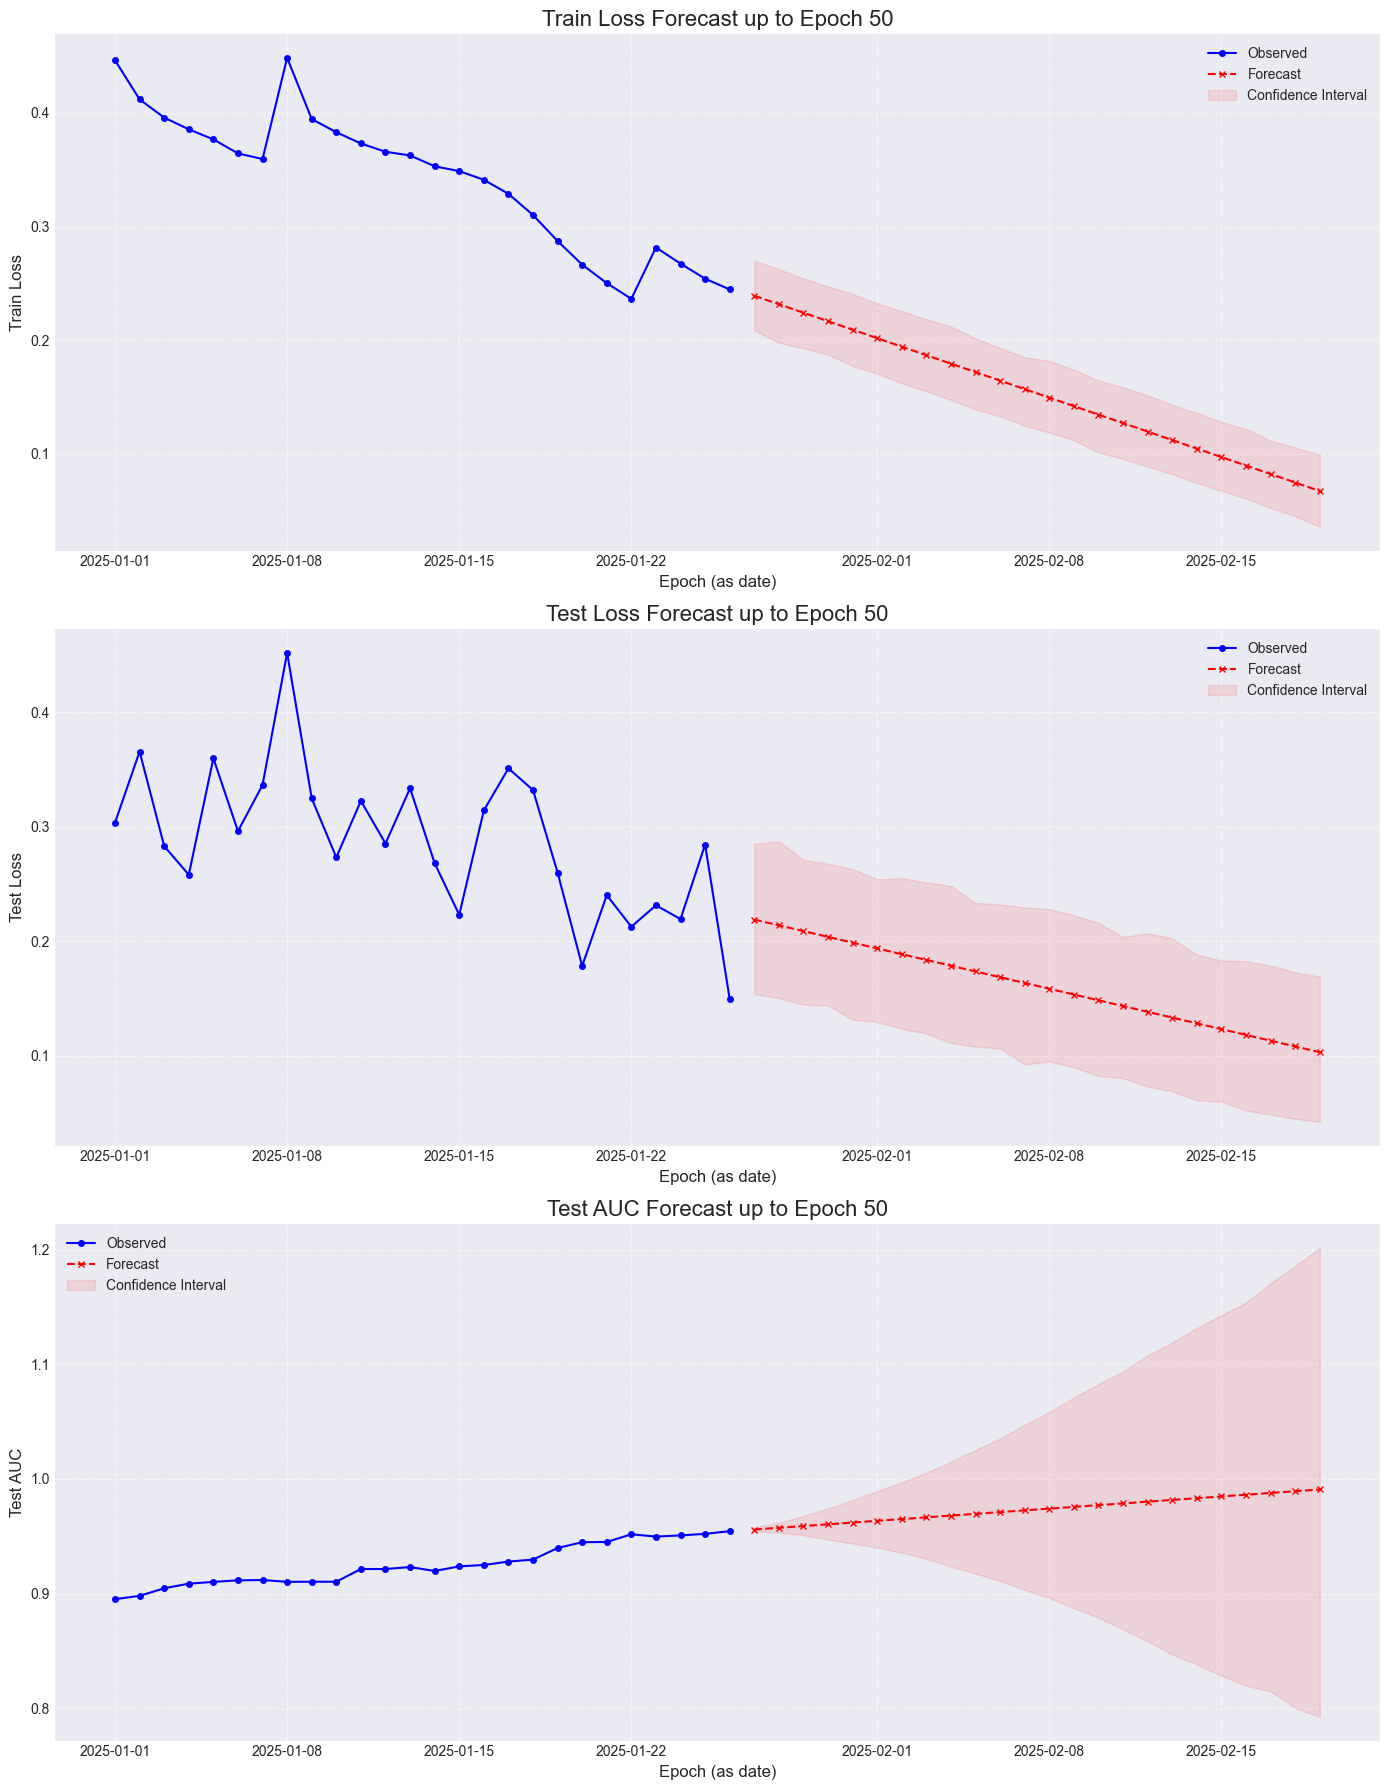

00:21:09 - cmdstanpy - INFO - Chain [1] start processing
00:21:09 - cmdstanpy - INFO - Chain [1] done processing
00:21:09 - cmdstanpy - INFO - Chain [1] start processing
00:21:10 - cmdstanpy - INFO - Chain [1] done processing



--- Train Loss Forecast Summary ---
  Last Observed (Epoch 26): 0.2446
  First Forecast (Epoch 27): 0.2390
  Forecasted at Epoch 50: 0.0670


00:21:10 - cmdstanpy - INFO - Chain [1] start processing
00:21:10 - cmdstanpy - INFO - Chain [1] done processing



--- Test Loss Forecast Summary ---
  Last Observed (Epoch 26): 0.1496
  First Forecast (Epoch 27): 0.2190
  Forecasted at Epoch 50: 0.1032

--- Test AUC Forecast Summary ---
  Last Observed (Epoch 26): 0.9544
  First Forecast (Epoch 27): 0.9559
  Forecasted at Epoch 50: 0.9908


In [28]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import numpy as np

# -----------------------------
# Parse the log data
# -----------------------------
log_data = """
[Starting phase 1: Adapter Training]
Epoch 1/7 -> Train Loss: 0.4464, Test Loss: 0.3038, Test AUC: 0.8951
-> New best model saved with AUC: 0.8951
Epoch 2/7 -> Train Loss: 0.4119, Test Loss: 0.3658, Test AUC: 0.8980
-> New best model saved with AUC: 0.8980
Epoch 3/7 -> Train Loss: 0.3959, Test Loss: 0.2832, Test AUC: 0.9046
-> New best model saved with AUC: 0.9046
Epoch 4/7 -> Train Loss: 0.3856, Test Loss: 0.2582, Test AUC: 0.9086
-> New best model saved with AUC: 0.9086
Epoch 5/7 -> Train Loss: 0.3767, Test Loss: 0.3599, Test AUC: 0.9102
-> New best model saved with AUC: 0.9102
Epoch 6/7 -> Train Loss: 0.3644, Test Loss: 0.2963, Test AUC: 0.9115
-> New best model saved with AUC: 0.9115
Epoch 7/7 -> Train Loss: 0.3594, Test Loss: 0.3366, Test AUC: 0.9118
-> New best model saved with AUC: 0.9118

[Starting phase 2: Full Fine-Tuning]
Epoch 8/25 -> Train Loss: 0.4485, Test Loss: 0.4520, Test AUC: 0.9102
-> AUC did not improve. Patience: 1/5
Epoch 9/25 -> Train Loss: 0.3946, Test Loss: 0.3249, Test AUC: 0.9103
-> AUC did not improve. Patience: 2/5
Epoch 10/25 -> Train Loss: 0.3830, Test Loss: 0.2734, Test AUC: 0.9103
-> AUC did not improve. Patience: 3/5
Epoch 11/25 -> Train Loss: 0.3731, Test Loss: 0.3227, Test AUC: 0.9214
-> New best model saved with AUC: 0.9214
Epoch 12/25 -> Train Loss: 0.3658, Test Loss: 0.2855, Test AUC: 0.9214
-> New best model saved with AUC: 0.9214
Epoch 13/25 -> Train Loss: 0.3626, Test Loss: 0.3337, Test AUC: 0.9231
-> New best model saved with AUC: 0.9231
Epoch 14/25 -> Train Loss: 0.3530, Test Loss: 0.2683, Test AUC: 0.9197
-> AUC did not improve. Patience: 1/5
Epoch 15/25 -> Train Loss: 0.3488, Test Loss: 0.2232, Test AUC: 0.9237
-> New best model saved with AUC: 0.9237
Epoch 16/25 -> Train Loss: 0.3411, Test Loss: 0.3144, Test AUC: 0.9249
-> New best model saved with AUC: 0.9249
Epoch 17/25 -> Train Loss: 0.3288, Test Loss: 0.3511, Test AUC: 0.9279
-> New best model saved with AUC: 0.9279
Epoch 18/25 -> Train Loss: 0.3101, Test Loss: 0.3322, Test AUC: 0.9296
-> New best model saved with AUC: 0.9296
Epoch 19/25 -> Train Loss: 0.2872, Test Loss: 0.2601, Test AUC: 0.9397
-> New best model saved with AUC: 0.9397
Epoch 20/25 -> Train Loss: 0.2664, Test Loss: 0.1785, Test AUC: 0.9448
-> New best model saved with AUC: 0.9448
Epoch 21/25 -> Train Loss: 0.2501, Test Loss: 0.2404, Test AUC: 0.9450
-> New best model saved with AUC: 0.9450
Epoch 22/25 -> Train Loss: 0.2363, Test Loss: 0.2128, Test AUC: 0.9517
-> New best model saved with AUC: 0.9517
Epoch 23/37 -> Train Loss: 0.2815, Test Loss: 0.2315, Test AUC: 0.9497
-> AUC did not improve. Patience: 1/5
Epoch 24/37 -> Train Loss: 0.2673, Test Loss: 0.2195, Test AUC: 0.9507
-> AUC did not improve. Patience: 2/5
Epoch 25/37 -> Train Loss: 0.2540, Test Loss: 0.2845, Test AUC: 0.9521
-> AUC did not improve. Patience: 3/5
Epoch 26/37 -> Train Loss: 0.2446, Test Loss: 0.1496, Test AUC: 0.9544
-> New best model saved with AUC: 0.9544
""" # truncated for readability; use your full log

# Lists to store parsed values
epochs, train_losses, test_losses, test_aucs = [], [], [], []

pattern = r"Epoch (\d+)/\d+ -> Train Loss: ([\d.]+), Test Loss: ([\d.]+), Test AUC: ([\d.]+)"

for line in log_data.split('\n'):
    match = re.search(pattern, line)
    if match:
        epochs.append(int(match.group(1)))
        train_losses.append(float(match.group(2)))
        test_losses.append(float(match.group(3)))
        test_aucs.append(float(match.group(4)))

# -----------------------------
# Map epochs to dates
# -----------------------------
start_date = pd.to_datetime("2025-01-01")  # arbitrary start
dates = [start_date + pd.Timedelta(days=e-1) for e in epochs]

# Create series with dates as index
train_loss_series = pd.Series(train_losses, index=dates)
test_loss_series = pd.Series(test_losses, index=dates)
test_auc_series = pd.Series(test_aucs, index=dates)

# Forecast horizon
target_epoch = 50
n_forecast_steps = target_epoch - len(epochs)
forecast_dates = [dates[-1] + pd.Timedelta(days=i) for i in range(1, n_forecast_steps + 1)]

# -----------------------------
# Prophet forecasting function
# -----------------------------
def prophet_forecast(series, steps, forecast_dates, title):
    df = pd.DataFrame({
        'ds': series.index,
        'y': series.values
    })
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False,
        seasonality_mode='additive'
    )
    model.fit(df)

    future = pd.DataFrame({'ds': list(series.index) + forecast_dates})
    forecast = model.predict(future)

    observed = forecast[forecast['ds'] <= series.index[-1]]
    predicted = forecast[forecast['ds'] > series.index[-1]]

    return observed, predicted

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 18))
plt.style.use('seaborn-v0_8-darkgrid')

plot_info = [
    (train_loss_series, 'Train Loss', axes[0]),
    (test_loss_series, 'Test Loss', axes[1]),
    (test_auc_series, 'Test AUC', axes[2])
]

for series, title, ax in plot_info:
    # Fit model and forecast
    df = pd.DataFrame({'ds': series.index, 'y': series.values})
    model = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=False)
    model.fit(df)

    future_dates = pd.DataFrame({'ds': list(series.index) + forecast_dates})
    forecast = model.predict(future_dates)

    # Plot observed from original series
    ax.plot(series.index, series.values, label='Observed', color='blue', marker='o', markersize=4)

    # Plot forecast for future only
    predicted = forecast[forecast['ds'] > series.index[-1]]
    ax.plot(predicted['ds'], predicted['yhat'], label='Forecast', color='red', linestyle='--', marker='x', markersize=4)

    # Confidence interval
    ax.fill_between(predicted['ds'], predicted['yhat_lower'], predicted['yhat_upper'],
                    color='red', alpha=0.1, label='Confidence Interval')

    ax.set_title(f'{title} Forecast up to Epoch {target_epoch}', fontsize=16)
    ax.set_xlabel('Epoch (as date)', fontsize=12)
    ax.set_ylabel(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

# -----------------------------
# Print forecast summary
# -----------------------------
for series_name, series in zip(['Train Loss', 'Test Loss', 'Test AUC'],
                               [train_loss_series, test_loss_series, test_auc_series]):
    _, predicted = prophet_forecast(series, n_forecast_steps, forecast_dates, series_name)
    print(f"\n--- {series_name} Forecast Summary ---")
    print(f"  Last Observed (Epoch {len(series)}): {series.iloc[-1]:.4f}")
    print(f"  First Forecast (Epoch {len(series)+1}): {predicted['yhat'].iloc[0]:.4f}")
    print(f"  Forecasted at Epoch {target_epoch}: {predicted['yhat'].iloc[-1]:.4f}")
